In [26]:
# FaceInsight - Age & Gender Prediction (Fast Training Version)
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.17.0


In [27]:
# Configuration
folder_path = r"C:\Users\ASUS\Downloads\Keras Functional Model\FaceInsight\UTKFace"
models_dir = r"C:\Users\ASUS\Downloads\Keras Functional Model\FaceInsight\models"
os.makedirs(models_dir, exist_ok=True)

In [28]:
# Load data into DataFrame with error handling
age = []
gender = []
img_path = []

for file in os.listdir(folder_path):
    parts = file.split('_')
    if len(parts) >= 2:
        try:
            age.append(int(parts[0]))
            gender.append(int(parts[1]))
            img_path.append(file)
        except ValueError:
            continue  # Skip files with invalid format

print(f"Loaded {len(age)} images")

Loaded 23708 images


In [29]:
# Create DataFrame
df = pd.DataFrame({
    'age': age,
    'gender': gender,
    'img': img_path
})

print(f"Total samples: {len(df)}")
df.head()

Total samples: 23708


,age,gender,img
0,100,0,100_0_0_20170112213500903.jpg.chip.jpg
1,100,0,100_0_0_20170112215240346.jpg.chip.jpg
2,100,1,100_1_0_20170110183726390.jpg.chip.jpg
3,100,1,100_1_0_20170112213001988.jpg.chip.jpg
4,100,1,100_1_0_20170112213303693.jpg.chip.jpg


In [30]:
# Train/Test split - Using 5000 training images for faster training
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = df_shuffled.iloc[:5000]  # 5000 training images
test_df = df_shuffled.iloc[5000:6000]  # 1000 test images
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

Train: 5000, Test: 1000


In [31]:
# Custom Data Generator with better augmentation for higher accuracy
class FaceDataGenerator(Sequence):
    def __init__(self, dataframe, directory, batch_size=32, target_size=(128, 128), 
                 shuffle=True, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.directory = directory
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.dataframe))
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.dataframe.iloc[batch_indices]
        
        images = []
        ages = []
        genders = []
        
        for _, row in batch_df.iterrows():
            img_path = os.path.join(self.directory, row['img'])
            img = load_img(img_path, target_size=self.target_size)
            img_array = img_to_array(img)
            
            # Enhanced augmentation for better accuracy
            if self.augment:
                # Random horizontal flip
                if np.random.random() > 0.5:
                    img_array = np.fliplr(img_array)
                # Random brightness adjustment
                brightness = np.random.uniform(0.8, 1.2)
                img_array = np.clip(img_array * brightness, 0, 255)
            
            # MobileNetV2 preprocessing
            img_array = preprocess_input(img_array)
            
            images.append(img_array)
            ages.append(row['age'])
            genders.append(row['gender'])
        
        X = np.array(images)
        y = {
            'age': np.array(ages, dtype=np.float32),
            'gender': np.array(genders, dtype=np.float32)
        }
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [32]:
# Create data generators (128x128 for faster processing)
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_gen = FaceDataGenerator(train_df, folder_path, batch_size=BATCH_SIZE, 
                               target_size=IMG_SIZE, shuffle=True, augment=True)
test_gen = FaceDataGenerator(test_df, folder_path, batch_size=BATCH_SIZE, 
                              target_size=IMG_SIZE, shuffle=False, augment=False)

print(f"Train batches: {len(train_gen)}, Test batches: {len(test_gen)}")

Train batches: 157, Test batches: 32


In [33]:
# Build Model - MobileNetV2 (faster than ResNet50, good accuracy)
base_model = MobileNetV2(include_top=False, input_shape=(128, 128, 3), weights='imagenet')
base_model.trainable = False  # Freeze base model

# Build head layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

# Shared dense layer
shared = Dense(256, activation='relu')(x)
shared = BatchNormalization()(shared)
shared = Dropout(0.4)(shared)

# Age branch (regression)
age_branch = Dense(128, activation='relu')(shared)
age_branch = Dropout(0.3)(age_branch)
age_output = Dense(1, activation='linear', name='age')(age_branch)

# Gender branch (binary classification)
gender_branch = Dense(128, activation='relu')(shared)
gender_branch = Dropout(0.3)(gender_branch)
gender_output = Dense(1, activation='sigmoid', name='gender')(gender_branch)

# Create model
model = Model(inputs=base_model.input, outputs=[age_output, gender_output])
print(f"Total params: {model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Total params: 2,658,114


In [34]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,658,114 (10.14 MB)

 Trainable params: 397,058 (1.51 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [35]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'age': 'mae',
        'gender': 'binary_crossentropy'
    },
    metrics={
        'age': 'mae',
        'gender': 'accuracy'
    },
    loss_weights={
        'age': 0.5,
        'gender': 0.5
    }
)

In [36]:
# Training callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3
    )
]

In [37]:
# Train the model - 10 epochs for faster training
EPOCHS = 10

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining complete!")
print(f"Best validation Age MAE: {min(history.history['val_age_mae']):.2f} years")
print(f"Best validation Gender Accuracy: {max(history.history['val_gender_accuracy'])*100:.1f}%")

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 410ms/step - age_loss: 12.0373 - age_mae: 24.1005 - gender_accuracy: 0.7207 - gender_loss: 0.3039 - loss: 12.3548 - val_age_loss: 5.0972 - val_age_mae: 10.2146 - val_gender_accuracy: 0.8170 - val_gender_loss: 0.2069 - val_loss: 5.3148 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 219ms/step - age_loss: 5.0073 - age_mae: 9.9982 - gender_accuracy: 0.7830 - gender_loss: 0.2493 - loss: 5.2483 - val_age_loss: 4.1658 - val_age_mae: 8.3594 - val_gender_accuracy: 0.8220 - val_gender_loss: 0.2084 - val_loss: 4.3902 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 209ms/step - age_loss: 4.7218 - age_mae: 9.4700 - gender_accuracy: 0.8055 - gender_loss: 0.2240 - loss: 4.9597 - val_age_loss: 4.1551 - val_age_mae: 8.3539 - val_gender_accuracy: 0.8470 - val_gender_loss: 0.1855 - val_loss: 4.3630 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 219ms/step - age_loss: 4.6413 - age_mae: 9.2578 - gende

In [38]:
# Save the trained model
model_path = os.path.join(models_dir, 'face_insight_model.keras')
model.save(model_path)
print(f"Model saved to {model_path}")

Model saved to C:\Users\ASUS\Downloads\Keras Functional Model\FaceInsight\models\face_insight_model.keras


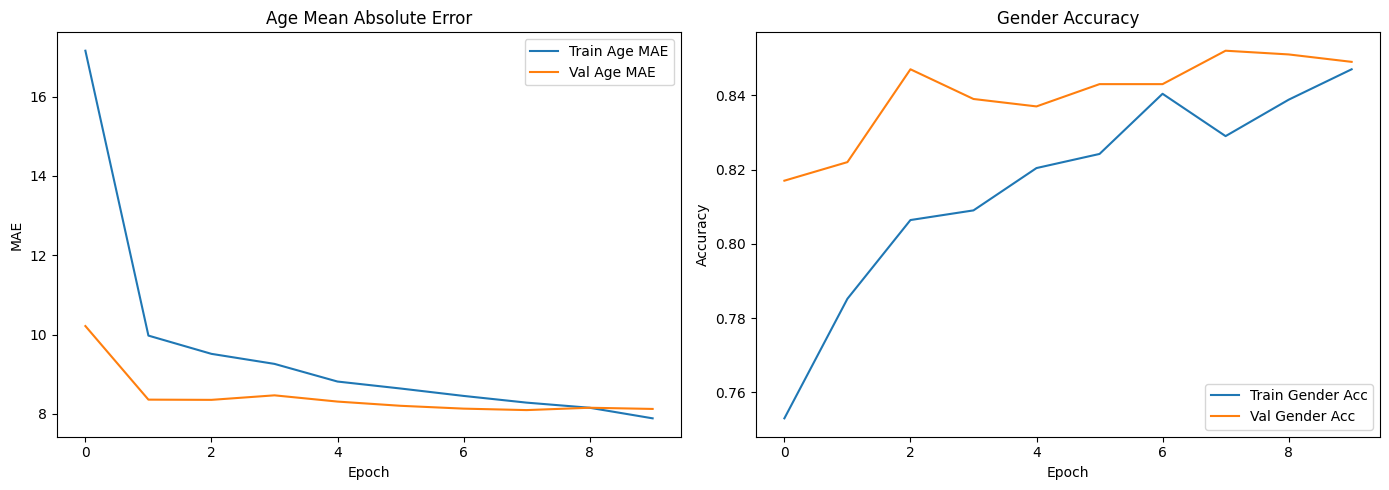

In [39]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age MAE
axes[0].plot(history.history['age_mae'], label='Train Age MAE')
axes[0].plot(history.history['val_age_mae'], label='Val Age MAE')
axes[0].set_title('Age Mean Absolute Error')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE')
axes[0].legend()

# Gender Accuracy
axes[1].plot(history.history['gender_accuracy'], label='Train Gender Acc')
axes[1].plot(history.history['val_gender_accuracy'], label='Val Gender Acc')
axes[1].set_title('Gender Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
# Test prediction on a sample image
sample_img_name = test_df.iloc[0]['img']
sample_img_path = os.path.join(folder_path, sample_img_name)

# Load and preprocess image (128x128)
img = load_img(sample_img_path, target_size=(128, 128))
img_array = img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array, verbose=0)
pred_age = predictions[0][0][0]
pred_gender = 'Male' if predictions[1][0][0] > 0.5 else 'Female'
confidence = predictions[1][0][0] if predictions[1][0][0] > 0.5 else 1 - predictions[1][0][0]

# Actual values
actual_age = test_df.iloc[0]['age']
actual_gender = 'Male' if test_df.iloc[0]['gender'] == 1 else 'Female'

print(f"Predicted: Age={pred_age:.1f}, Gender={pred_gender} ({confidence*100:.1f}% confidence)")
print(f"Actual: Age={actual_age}, Gender={actual_gender}")

Predicted: Age=20.8, Gender=Female (86.1% confidence)
Actual: Age=18, Gender=Female
